In [6]:
# ------------------------------------------------------------------ #
#  Notebook 03 · Cohort Retention Analysis                           #
#  Input : data/processed/retail_clean.parquet                       #
#  Output: data/processed/cohort_matrix.parquet                      #
# ------------------------------------------------------------------ #

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

CLEAN_PATH = r'E:\Projects\python\E-Commerce Customer Intelligence Platform\data\processed\retail_clean.parquet'
SAVE_PATH  = r'E:\Projects\python\E-Commerce Customer Intelligence Platform\data\processed\cohort_matrix.parquet'

In [2]:
df = pd.read_parquet(CLEAN_PATH)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# A cohort is defined by the month a customer made their very first purchase.
# Every subsequent purchase is then tracked relative to that first month.

df['OrderMonth'] = df['InvoiceDate'].dt.to_period('M')

cohort_month = (
    df.groupby('Customer ID')['OrderMonth']
    .min()
    .reset_index()
    .rename(columns={'OrderMonth': 'CohortMonth'})
)

df = df.merge(cohort_month, on='Customer ID', how='left')

# CohortIndex = how many months after acquisition this purchase occurred.
# 0 means the customer purchased in their first month.
df['CohortIndex'] = (
    df['OrderMonth'].dt.to_timestamp() - df['CohortMonth'].dt.to_timestamp()
).dt.days // 30

print(f'Cohorts spanning: {df["CohortMonth"].min()} to {df["CohortMonth"].max()}')
print(f'Max cohort index: {df["CohortIndex"].max()} months')
df[['Customer ID', 'OrderMonth', 'CohortMonth', 'CohortIndex']].head()

Cohorts spanning: 2009-12 to 2011-12
Max cohort index: 24 months


,Customer ID,OrderMonth,CohortMonth,CohortIndex
0,13085.0,2009-12,2009-12,0
1,13085.0,2009-12,2009-12,0
2,13085.0,2009-12,2009-12,0
3,13085.0,2009-12,2009-12,0
4,13085.0,2009-12,2009-12,0


## 1. Cohort Retention Matrix

For each cohort (acquisition month), we count how many unique customers
returned in each subsequent month. Dividing by the cohort's starting size
gives a retention rate — the percentage of original customers still active
at each point in time.

In [3]:
# Count distinct customers per cohort and month index.
cohort_data = (
    df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID']
    .nunique()
    .reset_index()
    .rename(columns={'Customer ID': 'Customers'})
)

# Pivot to a matrix: rows = cohort month, columns = months since acquisition.
cohort_matrix = cohort_data.pivot_table(
    index='CohortMonth',
    columns='CohortIndex',
    values='Customers'
)

# Divide every row by its cohort size (column 0) to get retention rates.
cohort_size = cohort_matrix[0]
retention   = cohort_matrix.divide(cohort_size, axis=0).round(3)

print(f'Matrix shape: {retention.shape}')
print(f'\nCohort sizes (first month customer count):')
print(cohort_size)

Matrix shape: (25, 25)

Cohort sizes (first month customer count):
CohortMonth
2009-12    952.0
2010-01    382.0
2010-02    375.0
2010-03    439.0
2010-04    293.0
2010-05    254.0
2010-06    267.0
2010-07    186.0
2010-08    162.0
2010-09    239.0
2010-10    375.0
2010-11    326.0
2010-12     76.0
2011-01     72.0
2011-02    125.0
2011-03    179.0
2011-04    106.0
2011-05    111.0
2011-06    108.0
2011-07    101.0
2011-08    106.0
2011-09    188.0
2011-10    221.0
2011-11    191.0
2011-12     28.0
Freq: M, Name: 0, dtype: float64


## 2. Retention Heatmap

The heatmap shows retention rates across all cohorts simultaneously.
Each row is an acquisition cohort, each column is months since acquisition.
Darker cells indicate higher retention. The diagonal pattern of empty cells
is expected — newer cohorts simply have not had time to reach later months.

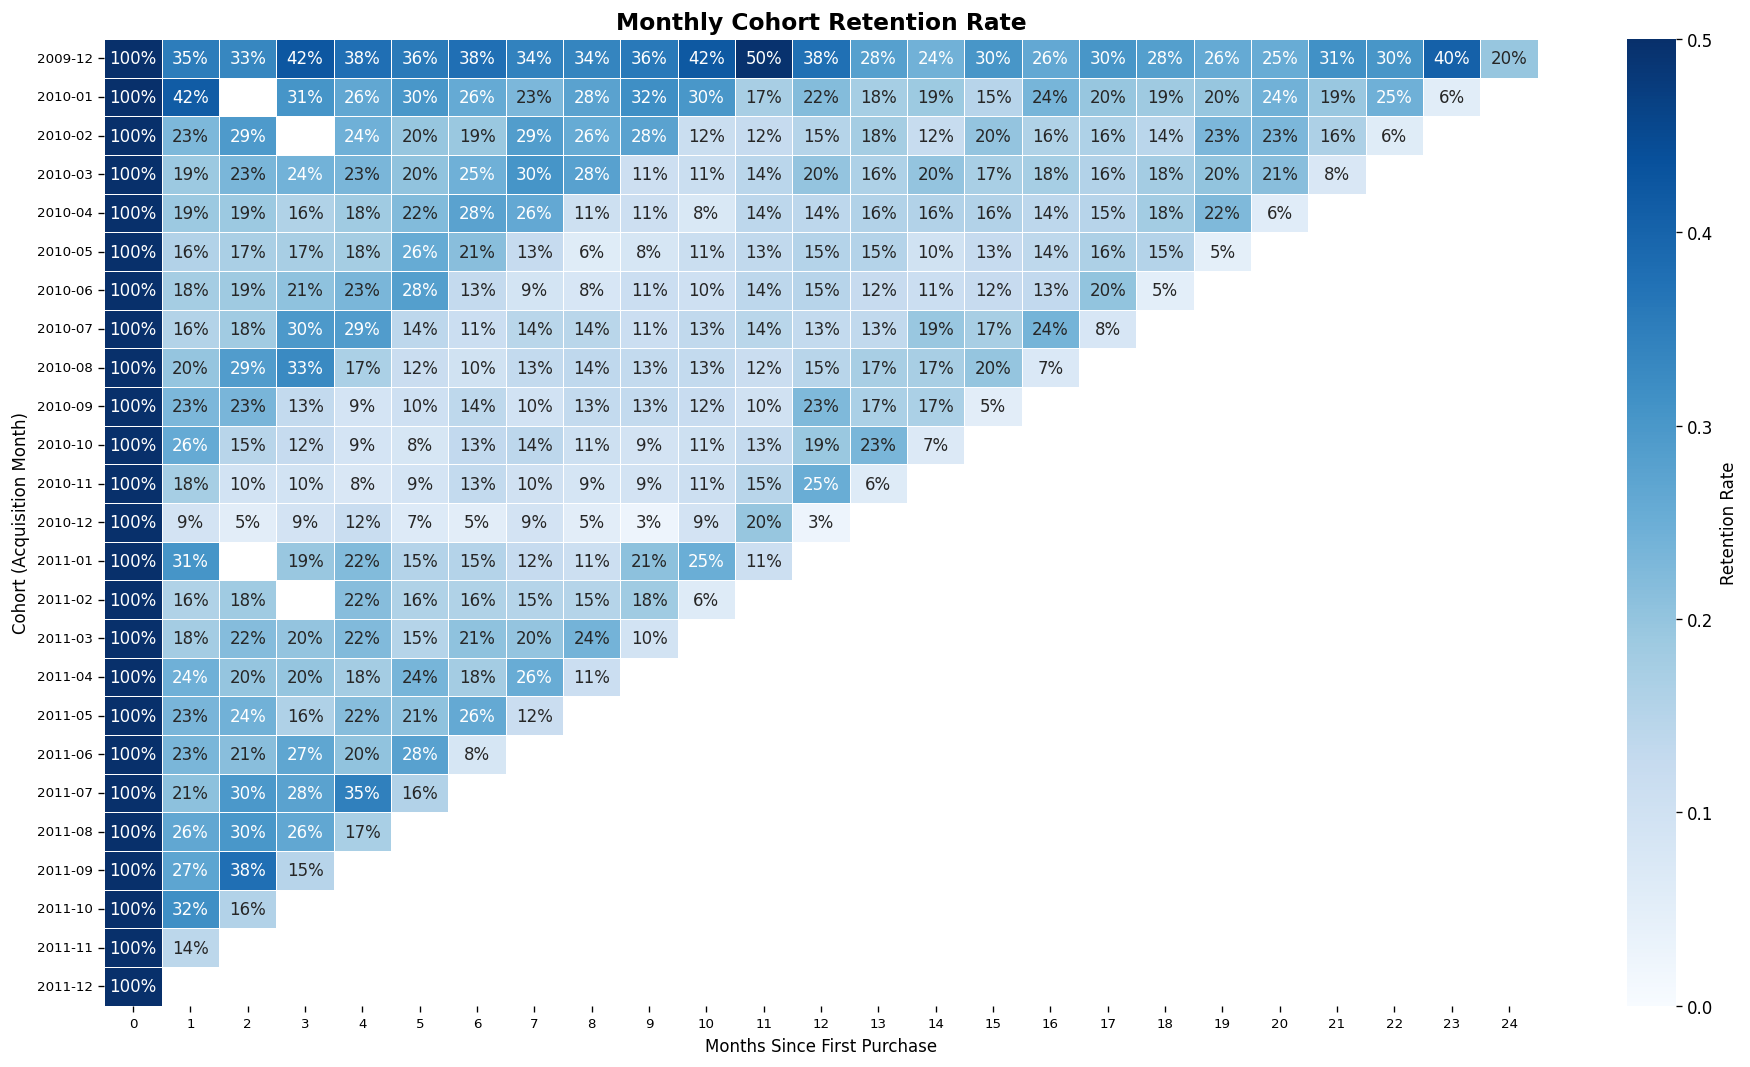

In [4]:
fig, ax = plt.subplots(figsize=(16, 9))

sns.heatmap(
    retention,
    annot=True,
    fmt='.0%',
    cmap='Blues',
    vmin=0,
    vmax=0.5,
    linewidths=0.3,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Retention Rate'}
)

ax.set_title('Monthly Cohort Retention Rate', fontsize=14, fontweight='bold')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort (Acquisition Month)')
ax.set_yticklabels([str(p) for p in retention.index], rotation=0, fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)

plt.tight_layout()
plt.show()

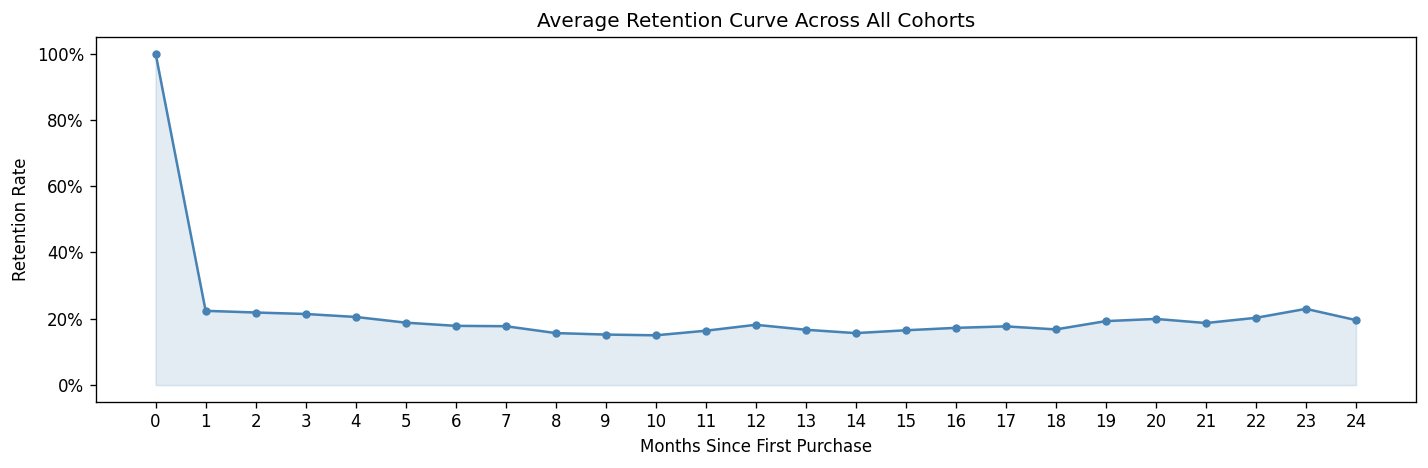

Saved: E:\Projects\python\E-Commerce Customer Intelligence Platform\data\processed\cohort_matrix.parquet
Shape: (25, 25)


In [7]:
# Average retention across all cohorts at each month index.
# This gives a single curve summarising the typical customer lifecycle.

avg_retention = retention.mean(axis=0).dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(avg_retention.index, avg_retention.values, marker='o', ms=4, color='steelblue')
ax.fill_between(avg_retention.index, avg_retention.values, alpha=0.15, color='steelblue')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_title('Average Retention Curve Across All Cohorts')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Retention Rate')
ax.set_xticks(avg_retention.index)
plt.tight_layout()
plt.show()

# Save the retention matrix for use in the dashboard
retention.to_parquet(SAVE_PATH)
print(f'Saved: {SAVE_PATH}')
print(f'Shape: {retention.shape}')